### ATLAS 2010 14293 cuts from checkmate

In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
from collections import OrderedDict
import pylhe
import glob
import pyslha

delphesDir = os.path.abspath("../../MG5/Delphes")
os.environ['ROOT_INCLUDE_PATH'] = os.path.join(delphesDir,"external")

import ROOT
import xml.etree.ElementTree as ET


ROOT.gSystem.Load(os.path.join(delphesDir,"libDelphes.so"))

ROOT.gInterpreter.Declare('#include "classes/SortableObject.h"')
ROOT.gInterpreter.Declare('#include "classes/DelphesClasses.h"')
ROOT.gInterpreter.Declare('#include "external/ExRootAnalysis/ExRootTreeReader.h"')

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 600}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=2.5)
cm = plt.cm.get_cmap('RdYlBu')

Welcome to JupyROOT 6.26/10


In [2]:
inputFiles = ['../DMSimp_vector_0j_2500_300_atlas/Events/run_03/2500_300_delphes_events.root',
              '../DMSimp_vector_1j_2500_300_atlas/Events/run_03/2500_300_delphes_events.root']
# inputFiles = ['../DMSimp_vector_0j_2500_300_atlas/Events/run_02/2500_900_delphes_events.root',
#               '../DMSimp_vector_1j_2500_300_atlas/Events/run_02/2500_900_delphes_events.root']
# inputFiles = ['../DMSimp_vector_0j_2500_300_twojet/Events/run_01/vector_2500_300_delphes_events.root',
#               '../DMSimp_vector_1j_2500_300_twojet/Events/run_01/vector_2500_300_delphes_events.root',
#               '../DMSimp_vector_2j_2500_300_twojet/Events/run_01/vector_2500_300_delphes_events.root']
# inputFiles = ['../DMSimp_vector_all_2500_300_atlas/Events/run_02/vector_2500_900_delphes_events.root']

In [3]:
parameters = {}
for file in inputFiles:
    banner = list(glob.glob(os.path.dirname(file)+'/*banner.txt'))
    if len(banner) != 1:
        print('%i banner files found for %s!' %(len(banner),label))
        break
    else:
        banner = banner[0]
    xtree = ET.parse(banner)
    xroot = xtree.getroot()
    xsecPB = eval(xroot.find('init').text.split()[-2])
    slha = xroot.find('header').find('slha').text
    pars = pyslha.readSLHA(slha)
    mMed = pars.blocks['MASS'][55]
    mDM = pars.blocks['MASS'][52]
    gVq = pars.blocks['DMINPUTS'][4] # Mediator-quark vector coupling
    gAq = pars.blocks['DMINPUTS'][10] # Mediator-quark axial coupling
    gVx = pars.blocks['DMINPUTS'][2] # Mediator-DM vector coupling
    gAx = pars.blocks['DMINPUTS'][3] # Mediator-DM axial coupling
    parameters = {'xsec(pb)' : xsecPB, 'mMed' : mMed, 'mDM' : mDM, 
                         'gVq' : gVq, 'gAq' : gAq, 'gVx' : gVx, 'gAx' : gAx}
    print('mMed = %1.2f GeV, mDM = %1.2f GeV, cross-section (pre-matching) = %1.3e pb' %(mMed,mDM,xsecPB))

mMed = 2500.00 GeV, mDM = 300.00 GeV, cross-section (pre-matching) = 1.060e-01 pb
mMed = 2500.00 GeV, mDM = 300.00 GeV, cross-section (pre-matching) = 9.635e-02 pb


In [6]:
### ATLAS PRESELECTION ###
## jets
pTjmin = 50
etamax_j = 2.8
pTj1min = 200.
etamax = 2.4
## MET
minMET = 300.
## Electrons
pTmin_el = 7.
nMax_el = 0
etamax_el = 2.47
## Muons
pTmin_mu = 6.
nMax_mu = 0
etamax_mu = 2.7
## Photons
pTmin_a = 150
etamax_a = 2.37
## Meff
MEFFmin = 800.
## Njets
Njetmin = 2
Njetmax = 3
## phi
phiHighmin = 0.8
phiLowmin = 0.4
## eta
etajetmax = 2.0
## ptjet
ptjetmin = 250.
## metrelative
metrelmin = 22
## meff_sr
meff_srmin = 2800
meff_srmax = 3400
# overlap
etaLow = 1.37
etaHigh = 1.52


lumTot = 137.2
njets = []
yields = []
weights = []
totalweightPB = 0.0
# Keep track of yields for each dataset
cutFlowAll = {'Fullsample' : 0.0,
              '$N_{j}>2$ and $p_{T}>200$GeV': 0.0,
              '$m_{eff}>800$GeV': 0.0,
              'Electronveto' : 0.0,
              'Muonveto' : 0.0,
              '$p_{T}^{miss}>300$GeV': 0.0,
              '$N_{j} = [2,3]$': 0.0,
              'dPhiHigh': 0.0,
              'dPhiLow': 0.0,
              'pTjet': 0.0,
              'etajet': 0.0,
              'METrelative': 0.0,
              'meff': 0.0}

ntotal = 0

for inputFile in inputFiles:
    f = ROOT.TFile(inputFile,'read')
    tree = f.Get("Delphes")
    nevts = tree.GetEntries()

    for ievt in range(nevts):  
        
        HT, Meff = 0, 0 

        ntotal += 1
        tree.GetEntry(ievt)        

        jets = tree.Jet
        try:
            weightPB = tree.Weight.At(1).Weight
        except:
            weightPB = tree.Weight.At(0).Weight
        ns = weightPB*1e3*lumTot # number of signal events
        totalweightPB += weightPB

        missingET = tree.MissingET.At(0)
        electrons = tree.Electron
        muons = tree.Muon
        photons = tree.Photon
        
        # Filter muons:
        muonList = []
        for imu in range(muons.GetEntries()):
            muon = muons.At(imu)
            # add muons to PT
            missingET.MET += muon.PT
            if muon.PT < pTmin_mu:
                continue
            if np.abs(muon.Eta) > etamax_mu:
                continue
            muonList.append(muon)

        # Filter electrons:
        electronList = []
        for iel in range(electrons.GetEntries()):
            electron = electrons.At(iel)
            if electron.PT < pTmin_el:
                continue
            if np.abs(electron.Eta) > etamax_el:
                continue
            electronList.append(electron)

            
        # Filter photons
        photonList = []
        for ia in range(photons.GetEntries()):
            photon = photons.At(ia)
            if photon.PT < pTmin_a:
                continue
            if abs(photon.Eta) > etamax_a:
                continue
            if abs(photon.Eta) < etaLow or abs(photon.Eta) > etaHigh:
                photonList.append(photon)
       

        # Filter jets (using checkmate cut for SR jets)
        jetList = []
        for ijet in range(jets.GetEntries()):
            jet = jets.At(ijet)
            if jet.PT < 50:
                continue
            if abs(jet.Eta) > 2.8:
                continue
            jetList.append(jet)  
        jetList = sorted(jetList, key = lambda j: j.PT, reverse=True)
        
        for j in jetList:
            HT += j.PT
            Meff += j.PT
        Meff += missingET.MET
        
        
        ### before pre selection
        
        


        cutFlow = cutFlowAll
        cutFlow['Fullsample'] += ns

        # Apply cuts:
        ## Apply trigger efficiency

        ## N jet cut
        if (len(jetList) < 2) or (jetList[0].PT < pTj1min): continue
        cutFlow['$N_{j}>2$ and $p_{T}>200$GeV'] += ns
        ## Meff cut
        if Meff < MEFFmin: continue
        cutFlow['$m_{eff}>800$GeV'] += ns
        
        # Veto electrons
        if len(electronList) > nMax_el: continue  
        cutFlow['Electronveto'] += ns
        ## Veto muons
        if len(muonList) > nMax_mu: continue  
        cutFlow['Muonveto'] += ns
        
        ## Cut on MET
        if missingET.MET < minMET: continue              
        cutFlow['$p_{T}^{miss}>300$GeV'] += ns
        
        if len(jetList) < 2 or len(jetList) > 3: continue
        cutFlow['$N_{j} = [2,3]$'] += ns

        dPhiMin = 10
        for j in jetList:
            dPhiMin = min(np.abs(j.Phi-missingET.Phi), dPhiMin)
            
        if dPhiMin < phiHighmin: continue
        cutFlow['dPhiHigh'] += ns
        
        if len(jetList) > 3:
            dPhiMin = 10
            for j in jetList[3:]:
                dPhiMin = min(np.abs(j.Phi-missingET.Phi), dPhiMin)
            if dPhiMin < phiLowmin: continue
        cutFlow['dPhiLow'] += ns
        
        if jetList[0].PT < ptjetmin or jetList[1].PT < ptjetmin: continue     
        cutFlow['pTjet'] += ns
        
        for j in jetList[0:2]:
            if j.Eta > etajetmax: continue
        cutFlow['etajet'] += ns
        
        if missingET.MET/np.sqrt(HT) < metrelmin: continue
        cutFlow['METrelative'] += ns
        
        if Meff < meff_srmin or Meff > meff_srmax: continue
        cutFlow['meff'] += ns

        # Store relevant data        
#         yields.append(ns)
#         metAll.append(missingET.MET)  
#         meffAll.append(Meff)
#         njets.append(len(jetList))
#         weights.append(weightPB)

    f.Close()

print('\nCross-section (pb) = %1.3e\n' %totalweightPB)


for key,val in cutFlowAll.items():
    if key == 'Fullsample':
        continue
    cutFlowAll[key] = val/cutFlowAll['Fullsample']
cutFlowAll['Fullsample'] = 1.0


Cross-section (pb) = 1.005e-01



In [7]:
cutFlowAll

{'Fullsample': 1.0,
 '$N_{j}>2$ and $p_{T}>200$GeV': 0.8654644442998374,
 '$m_{eff}>800$GeV': 0.8128997605589761,
 'Electronveto': 0.8041108655752074,
 'Muonveto': 0.798458072250426,
 '$p_{T}^{miss}>300$GeV': 0.048715075184984115,
 '$N_{j} = [2,3]$': 0.04524597290496664,
 'dPhiHigh': 0.03328553871669432,
 'dPhiLow': 0.03328553871669432,
 'pTjet': 0.0037316593566024923,
 'etajet': 0.0037316593566024923,
 'METrelative': 0.002326477835437695,
 'meff': 0.0004170297366381168}

In [5]:
### ATLAS PRESELECTION ###
## jets
pTjmin = 50
etamax_j = 2.8
pTj1min = 200.
etamax = 2.4
## MET
minMET = 300.
## Electrons
pTmin_el = 7.
nMax_el = 0
etamax_el = 2.47
## Muons
pTmin_mu = 6.
nMax_mu = 0
etamax_mu = 2.7
## Photons
pTmin_a = 150
etamax_a = 2.37
## Meff
MEFFmin = 800.
## Njets
Njetmin = 2
Njetmax = 3
## phi
phiHighmin = 0.8
phiLowmin = 0.4
## eta
etajetmax = 2.0
## ptjet
ptjetmin = 250.
## metrelative
metrelmin = 22
## meff_sr
meff_srmin = 2800
meff_srmax = 3400

lumTot = 137.2
njets = []
yields = []
weights = []
totalweightPB = 0.0
# Keep track of yields for each dataset
cutFlowAll = {'Fullsample' : 0.0,
              '$N_{j}>2$ and $p_{T}>200$GeV': 0.0,
              '$m_{eff}>800$GeV': 0.0,
              'Electronveto' : 0.0,
              'Muonveto' : 0.0,
              '$p_{T}^{miss}>300$GeV': 0.0,
              '$N_{j} = [2,3]$': 0.0,
              'dPhiHigh': 0.0,
              'dPhiLow': 0.0,
              'pTjet': 0.0,
              'etajet': 0.0,
              'METrelative': 0.0,
              'meff': 0.0}

ntotal = 0

for inputFile in inputFiles:
    f = ROOT.TFile(inputFile,'read')
    tree = f.Get("Delphes")
    nevts = tree.GetEntries()

    for ievt in range(nevts):  
        
        HT, Meff = 0, 0 

        ntotal += 1
        tree.GetEntry(ievt)        

        jets = tree.Jet
        try:
            weightPB = tree.Weight.At(1).Weight
        except:
            weightPB = tree.Weight.At(0).Weight
        ns = weightPB*1e3*lumTot # number of signal events
        totalweightPB += weightPB

        missingET = tree.MissingET.At(0)
        electrons = tree.Electron
        muons = tree.Muon
        photons = tree.Photon
        
        # Filter muons:
        muonList = []
        for imu in range(muons.GetEntries()):
            muon = muons.At(imu)
            missingET.MET += muon.PT
            if muon.PT < pTmin_mu:
                continue
            if np.abs(muon.Eta) > etamax_mu:
                continue
            muonList.append(muon)

        # Filter electrons:
        electronList = []
        for iel in range(electrons.GetEntries()):
            electron = electrons.At(iel)
            if electron.PT < pTmin_el:
                continue
            if np.abs(electron.Eta) > etamax_el:
                continue
            electronList.append(electron)

            
        # Filter photons
        photonList = []
        for ia in range(photons.GetEntries()):
            photon = photons.At(ia)
            if photon.PT < pTmin_a:
                continue
            if abs(photon.Eta) > etamax_a:
                continue
            photonList.append(photon)
       

        # Filter jets
        jetList = []
        for ijet in range(jets.GetEntries()):
            jet = jets.At(ijet)
            if jet.PT < 20:
                continue
            if abs(jet.Eta) > 2.8:
                continue
            jetList.append(jet)  
        jetList = sorted(jetList, key = lambda j: j.PT, reverse=True)
        
        for j in jetList:
            HT += j.PT
            if j.PT > 50:
                Meff += j.PT
        Meff += missingET.MET


        cutFlow = cutFlowAll
        cutFlow['Fullsample'] += ns

        # Apply cuts:
        ## Apply trigger efficiency

        ## N jet cut
        if (len(jetList) < 2) or (jetList[0].PT < pTj1min): continue
        cutFlow['$N_{j}>2$ and $p_{T}>200$GeV'] += ns
        ## Meff cut
        if Meff < MEFFmin: continue
        cutFlow['$m_{eff}>800$GeV'] += ns
        
        # Veto electrons
        if len(electronList) > nMax_el: continue  
        cutFlow['Electronveto'] += ns
        ## Veto muons
        if len(muonList) > nMax_mu: continue  
        cutFlow['Muonveto'] += ns
        
        ## Cut on MET
        if missingET.MET < minMET: continue              
        cutFlow['$p_{T}^{miss}>300$GeV'] += ns
        
        if len(jetList) < 2 or len(jetList) > 3: continue
        cutFlow['$N_{j} = [2,3]$'] += ns

        dPhiMin = 10
        for j in jetList:
            dPhiMin = min(np.abs(j.Phi-missingET.Phi), dPhiMin)
            
        if dPhiMin < phiHighmin: continue
        cutFlow['dPhiHigh'] += ns
        
        if len(jetList) > 3:
            dPhiMin = 10
            for j in jetList[3:]:
                dPhiMin = min(np.abs(j.Phi-missingET.Phi), dPhiMin)
            if dPhiMin < phiLowmin: continue
        cutFlow['dPhiLow'] += ns
        
        if jetList[0].PT < ptjetmin or jetList[1].PT < ptjetmin: continue     
        cutFlow['pTjet'] += ns
        
        for j in jetList[0:2]:
            if j.Eta > etajetmax: continue
        cutFlow['etajet'] += ns
        
        if missingET.MET/np.sqrt(HT) < metrelmin: continue
        cutFlow['METrelative'] += ns
        
        if Meff < meff_srmin or Meff > meff_srmax: continue
        cutFlow['meff'] += ns

        # Store relevant data        
#         yields.append(ns)
#         metAll.append(missingET.MET)  
#         meffAll.append(Meff)
#         njets.append(len(jetList))
#         weights.append(weightPB)

    f.Close()

print('\nCross-section (pb) = %1.3e\n' %totalweightPB)


for key,val in cutFlowAll.items():
    if key == 'Fullsample':
        continue
    cutFlowAll[key] = val/cutFlowAll['Fullsample']
cutFlowAll['Fullsample'] = 1.0


Cross-section (pb) = 1.005e-01



In [6]:
cutFlowAll

{'Fullsample': 1.0,
 '$N_{j}>2$ and $p_{T}>200$GeV': 0.9014203032552139,
 '$m_{eff}>800$GeV': 0.8379000107054452,
 'Electronveto': 0.8289628882332908,
 'Muonveto': 0.8231830361621507,
 '$p_{T}^{miss}>300$GeV': 0.07344003909670904,
 '$N_{j} = [2,3]$': 0.058447333337510864,
 'dPhiHigh': 0.042067092211441434,
 'dPhiLow': 0.042067092211441434,
 'pTjet': 0.0023969589027147864,
 'etajet': 0.0023969589027147864,
 'METrelative': 0.001529867136040559,
 'meff': 0.00024010260817368192}

In [10]:
0.00024091098202635885/0.0015383672738300427

0.1566017336201956

In [4]:
### ATLAS PRESELECTION ###
## jets
pTjmin = 50
etamax_j = 2.8
pTj1min = 200.
etamax = 2.4
## MET
minMET = 300.
## Electrons
pTmin_el = 7.
nMax_el = 0
etamax_el = 2.47
## Muons
pTmin_mu = 6.
nMax_mu = 0
etamax_mu = 2.7
## Photons
pTmin_a = 150
etamax_a = 2.37
## Meff
MEFFmin = 800.
## Njets
Njetmin = 2
Njetmax = 3
## phi
phiHighmin = 0.8
phiLowmin = 0.4
## eta
etajetmax = 2.0
## ptjet
ptjetmin = 250.
## metrelative
metrelmin = 22
## meff_sr
meff_srmin = 2800
meff_srmax = 3400

lumTot = 137.2
njets = []
yields = []
weights = []
metAll = {'preselection': [], 'nj': [], 'dPhiHigh': [], 'dPhiLow': [], 'pTjet': [], 'etajet': [], 'METrelative': [],
          'meff': []}
meffAll = {'preselection': [], 'nj': [], 'dPhiHigh': [], 'dPhiLow': [], 'pTjet': [], 'etajet': [], 'METrelative': [],
          'meff': []}
pTj1 = {'dPhiLow': [], 'pTjet': [], 'etajet': [], 'METrelative': [], 'meff': []}
totalweightPB = 0.0
# Keep track of yields for each dataset
cutFlowAll = {'Fullsample' : 0.0,
              '$N_{j}>2$ or $p_{T}>200$GeV': 0.0,
              '$m_{eff}>800$GeV': 0.0,
              'Electronveto' : 0.0,
              'Muonveto' : 0.0,
              '$p_{T}^{miss}>300$GeV': 0.0,
              'nj': 0.0,
              'dPhiHigh': 0.0,
              'dPhiLow': 0.0,
              'pTjet': 0.0,
              'etajet': 0.0,
              'METrelative': 0.0,
              'meff': 0.0}

ntotal = 0
for inputFile in inputFiles:
    f = ROOT.TFile(inputFile,'read')
    tree = f.Get("Delphes")
    nevts = tree.GetEntries()

    for ievt in range(nevts):    

        ntotal += 1
        tree.GetEntry(ievt)        

        jets = tree.Jet
        try:
            weightPB = tree.Weight.At(1).Weight
        except:
            weightPB = tree.Weight.At(0).Weight
        ns = weightPB*1e3*lumTot # number of signal events
        totalweightPB += weightPB

        missingET = tree.MissingET.At(0)
    #         missingET = tree.GenMissingET.At(0)  # USE REAL MISSING ET!
        electrons = tree.Electron
        muons = tree.Muon
        photons = tree.Photon

        # Filter electrons:
        electronList = []
        for iel in range(electrons.GetEntries()):
            electron = electrons.At(iel)
            if electron.PT < pTmin_el:
                continue
            if np.abs(electron.Eta) > etamax_el:
                continue
            electronList.append(electron)

        # Filter muons:
        muonList = []
        for imu in range(muons.GetEntries()):
            muon = muons.At(imu)
            if muon.PT < pTmin_mu:
                continue
            if np.abs(muon.Eta) > etamax_mu:
                continue
            muonList.append(muon)
            
        # Filter photons
        photonList = []
        for ia in range(photons.GetEntries()):
            photon = photons.At(ia)
            if photon.PT < pTmin_a:
                continue
            if abs(photon.Eta) > etamax_a:
                continue
            photonList.append(photon)
       

        # Filter jets
        jetList = []
        for ijet in range(jets.GetEntries()):
            jet = jets.At(ijet)
            if jet.PT < 20:
                continue
            if abs(jet.Eta) > 2.8:
                continue
            jetList.append(jet)  
        jetList = sorted(jetList, key = lambda j: j.PT, reverse=True)    

        if len(jetList) == 1:
            deltaPhi1 = np.abs(jetList[0].Phi-missingET.Phi) 
        elif len(jetList) == 2:
            deltaPhi2 = np.abs((jetList[0].Phi + jetList[1].Phi) - missingET.Phi)
        elif len(jetList) == 3:
            deltaPhi3 = np.abs((jetList[0].Phi + jetList[1].Phi + jetList[2].Phi) - missingET.Phi)
        elif len(jetList) > 3:
            sumjet_phi = 0
            for j in jetList:
                sumjet_phi += j.Phi
            deltaPhi4 = np.abs(sumjet_phi - missingET.Phi)
        elif len(jetList) == 0:
            deltaPhi = 0.0
            
        deltaPhis = []
        sumjet_phi = 0.0
        for jet in jetList:
            sumjet_phi += jet.Phi
            
            
        ptJets, ptJets_etacut = [], []
        for j in jetList:
            if j.PT > 50:
                ptJets.append(j.PT)
            if j.PT > 50 and np.abs(j.Eta) < 2.8:
                ptJets_etacut.append(j.PT)
                
        if len(ptJets) > 0:    
            Meff = missingET.MET + ptJets[0]
            HT = np.array(ptJets_etacut).sum()
        else:
            Meff = 0
            HT = 0
        
        for j in jetList:
            if j.PT < 50:
                continue
            if np.abs(j.Eta) > 2.8:
                continue


        cutFlow = cutFlowAll
        cutFlow['Fullsample'] += ns

        # Apply cuts:
        ## Apply trigger efficiency

        ## N jet cut
        if len(jetList) < 2 or jetList[0].PT < pTj1min: continue
        cutFlow['$N_{j}>2$ or $p_{T}>200$GeV'] += ns
        ## Meff cut
        if Meff < MEFFmin: continue
        cutFlow['$m_{eff}>800$GeV'] += ns
        
        # Veto electrons
        if len(electronList) > nMax_el: continue  
        cutFlow['Electronveto'] += ns
        ## Veto muons
        if len(muonList) > nMax_mu: continue  
        cutFlow['Muonveto'] += ns
        
        ## Cut on MET
        if missingET.MET < minMET: continue              
        cutFlow['$p_{T}^{miss}>300$GeV'] += ns
        
        metAll['preselection'].append(missingET.MET)
        meffAll['preselection'].append(Meff)
        
        if len(jetList) < 2 or len(jetList) > 3: continue
        cutFlow['nj'] += ns
        metAll['nj'].append(missingET.MET)
        meffAll['nj'].append(Meff)
        
        if len(jetList) == 2:
            if deltaPhi2 < phiHighmin: continue
        elif len(jetList) == 3:
            if deltaPhi3 < phiHighmin: continue
        cutFlow['dPhiHigh'] += ns
        metAll['dPhiHigh'].append(missingET.MET)
        meffAll['dPhiHigh'].append(Meff)
        
        if len(jetList) > 3:
            if deltaPhi4 < phiLowmin: continue
        cutFlow['dPhiLow'] += ns 
        metAll['dPhiLow'].append(missingET.MET)
        meffAll['dPhiLow'].append(Meff)
        pTj1['dPhiLow'].append(ptJets[0])
        
        if jetList[0].PT < ptjetmin or jetList[1].PT < ptjetmin: continue
            
        cutFlow['pTjet'] += ns
        metAll['pTjet'].append(missingET.MET)
        meffAll['pTjet'].append(Meff)
        pTj1['pTjet'].append(ptJets[0])
        
        for j in jetList:
            if j.Eta > etajetmax: continue
#         if jetList[0].Eta > etajetmax: continue
        cutFlow['etajet'] += ns
        metAll['etajet'].append(missingET.MET)
        meffAll['etajet'].append(Meff)
        pTj1['etajet'].append(ptJets[0])
        
        if missingET.MET/np.sqrt(HT) < metrelmin: continue
        cutFlow['METrelative'] += ns
        metAll['METrelative'].append(missingET.MET)
        meffAll['METrelative'].append(Meff)
        pTj1['METrelative'].append(ptJets[0])
        
        if Meff < meff_srmin or Meff > meff_srmax: continue
        cutFlow['meff'] += ns
        metAll['meff'].append(missingET.MET)
        meffAll['meff'].append(Meff)
        pTj1['meff'].append(ptJets[0])

        # Store relevant data        
        yields.append(ns)
#         metAll.append(missingET.MET)  
#         meffAll.append(Meff)
        njets.append(len(jetList))
        weights.append(weightPB)

    f.Close()

print('\nCross-section (pb) = %1.3e\n' %totalweightPB)


for key,val in cutFlowAll.items():
    if key == 'Fullsample':
        continue
    cutFlowAll[key] = val/cutFlowAll['Fullsample']
cutFlowAll['Fullsample'] = 1.0


Cross-section (pb) = 1.005e-01



In [5]:
cutFlowAll

{'Fullsample': 1.0,
 '$N_{j}>2$ or $p_{T}>200$GeV': 0.9014203032552139,
 '$m_{eff}>800$GeV': 0.6471696761924991,
 'Electronveto': 0.6400721360741322,
 'Muonveto': 0.6353869954272787,
 '$p_{T}^{miss}>300$GeV': 0.07011439539265331,
 'nj': 0.05617823916612892,
 'dPhiHigh': 0.04933329387519411,
 'dPhiLow': 0.04933329387519411,
 'pTjet': 0.0029049120377926617,
 'etajet': 0.0029049120377926617,
 'METrelative': 0.0016137437641396862,
 'meff': 3.3373939275069995e-05}

In [15]:
0.00017026820409585082/0.0008052627438281973

0.21144428374570065

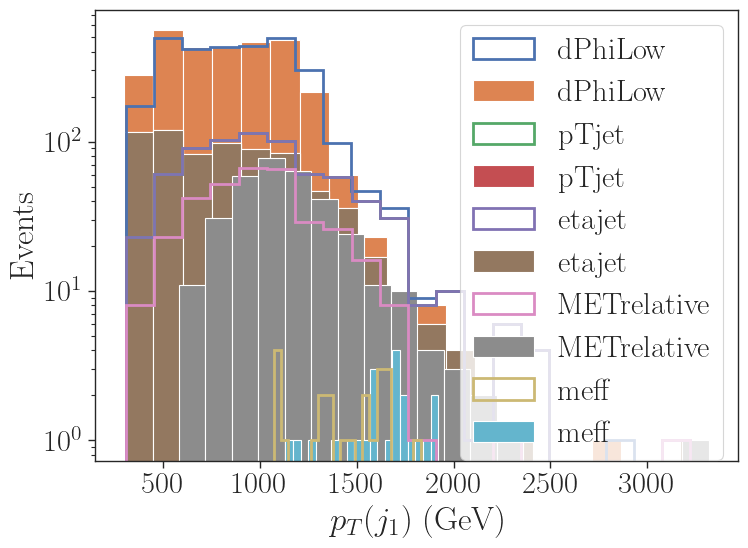

In [14]:
plt.figure(figsize=(8,6))
for label in pTj1.keys():
    plt.hist(pTj1[label], bins=20, histtype='step', label=label, linewidth=2)
    plt.hist(metAll[label], bins=20, label=label)
    
plt.xlabel(r'$p_{T}(j_{1})$ (GeV)')
plt.ylabel('Events')
plt.yscale('log')
plt.legend()

plt.tight_layout()

# plt.savefig('BM-atlas-cuts-meff.png')
plt.show()

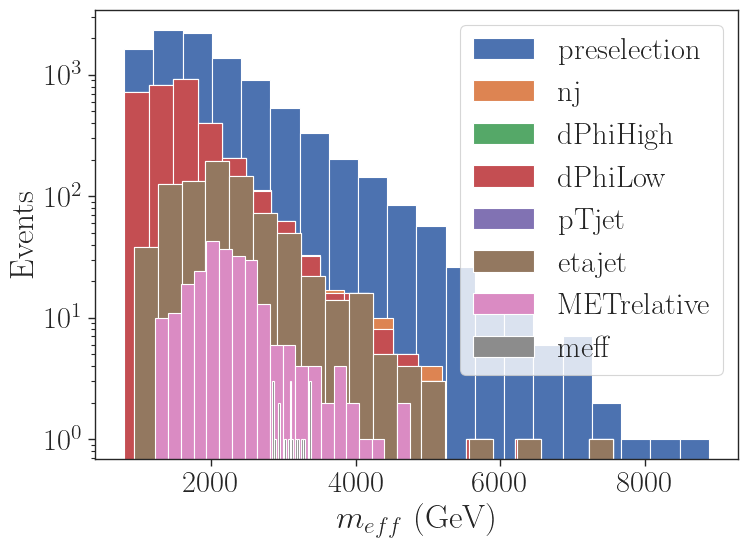

In [8]:
plt.figure(figsize=(8,6))
for label in meffAll.keys():
    plt.hist(meffAll[label], bins=20, label=label)
    
plt.xlabel(r'$m_{eff}$ (GeV)')
plt.ylabel('Events')
plt.yscale('log')
plt.legend()

plt.tight_layout()

# plt.savefig('BM-atlas-cuts-meff.png')
plt.show()

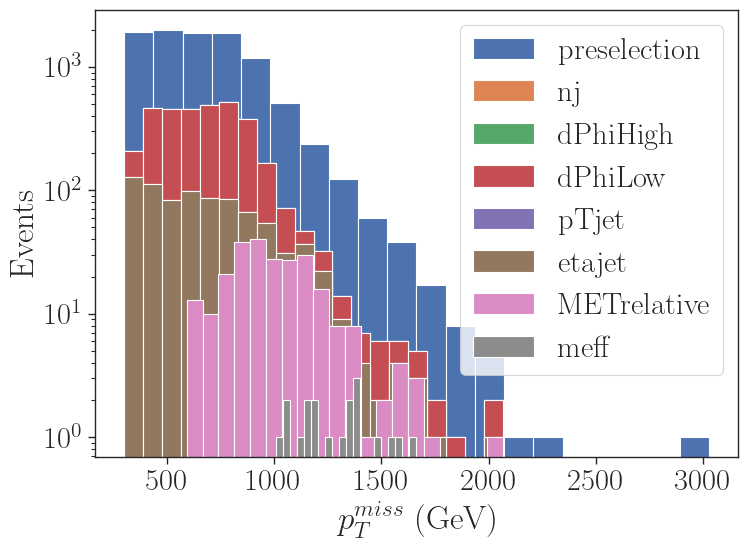

In [9]:
plt.figure(figsize=(8,6))
for label in metAll.keys():
    plt.hist(metAll[label], bins=20, label=label)
    
plt.xlabel(r'$p_{T}^{miss}$ (GeV)')
plt.ylabel('Events')
plt.yscale('log')
plt.legend()

plt.tight_layout()

# plt.savefig('BM-atlas-cuts-met.png')
plt.show()

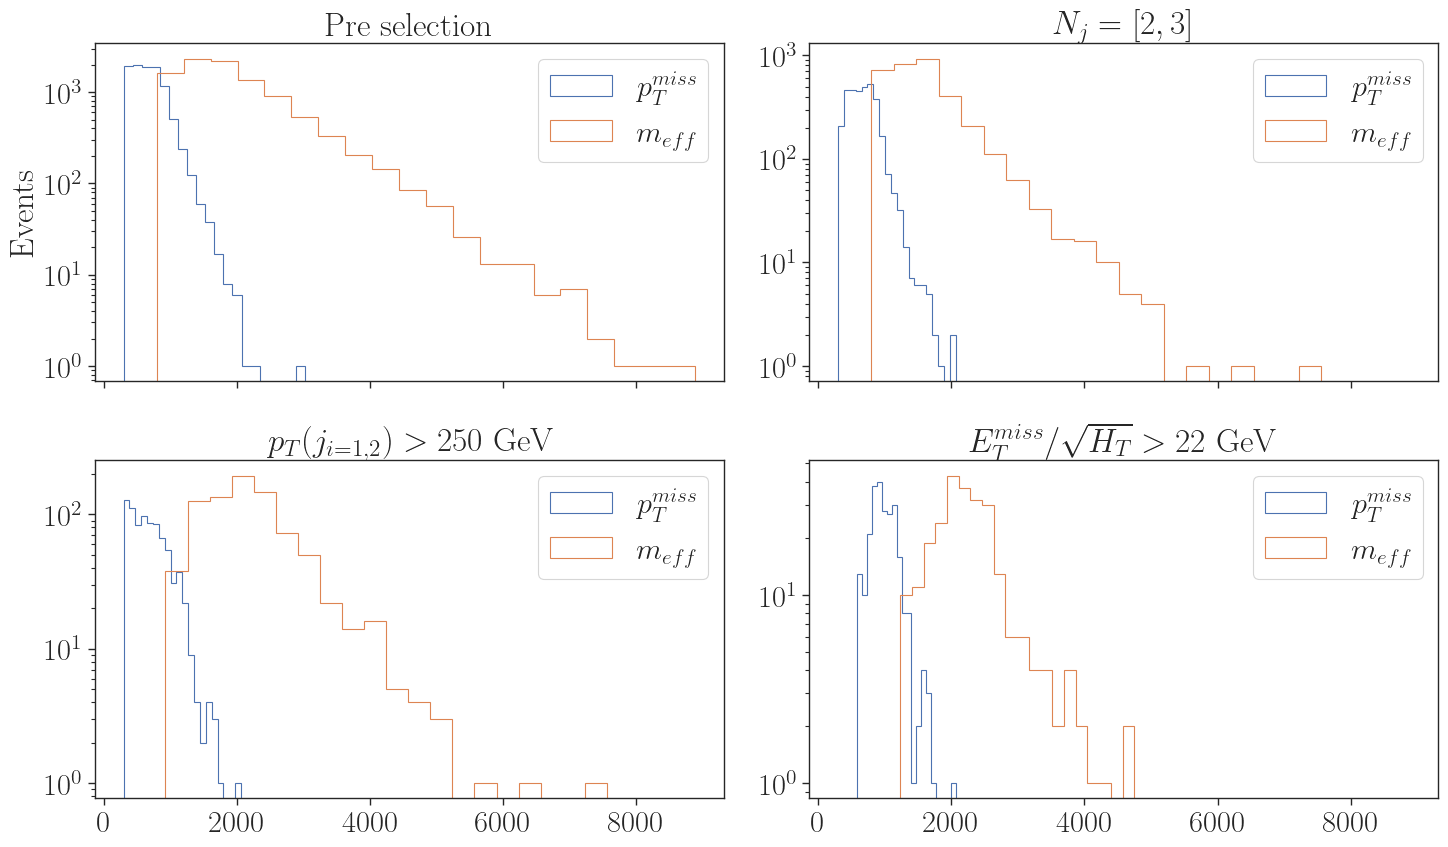

In [10]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 9), sharex=True)

ax[0,0].hist(metAll['preselection'], bins=20, label=r'$p_{T}^{miss}$', histtype='step')
ax[0,0].hist(meffAll['preselection'], bins=20, label=r'$m_{eff}$', histtype='step')

ax[0,0].set_title(r'Pre selection')
ax[0,0].legend()
ax[0,0].set_yscale('log')
ax[0,0].set_ylabel(r'Events')


ax[0,1].hist(metAll['nj'], bins=20, label=r'$p_{T}^{miss}$', histtype='step')
ax[0,1].hist(meffAll['nj'], bins=20, label=r'$m_{eff}$', histtype='step')

ax[0,1].set_title(r'$N_{j}=[2,3]$')
ax[0,1].legend()
ax[0,1].set_yscale('log')

ax[1,0].hist(metAll['pTjet'], bins=20, label=r'$p_{T}^{miss}$', histtype='step')
ax[1,0].hist(meffAll['pTjet'], bins=20, label=r'$m_{eff}$', histtype='step')

ax[1,0].set_title(r'$p_{T}(j_{i=1,2}) > 250$ GeV')
ax[1,0].legend()
ax[1,0].set_yscale('log')

ax[1,1].hist(metAll['METrelative'], bins=20, label=r'$p_{T}^{miss}$', histtype='step')
ax[1,1].hist(meffAll['METrelative'], bins=20, label=r'$m_{eff}$', histtype='step')

ax[1,1].set_title(r'$E_{T}^{miss}/\sqrt{H_{T}} > 22$ GeV')
ax[1,1].legend()
ax[1,1].set_yscale('log')



plt.tight_layout()
# plt.savefig('BM-atlas-cuts-meff-met.png')
plt.show()

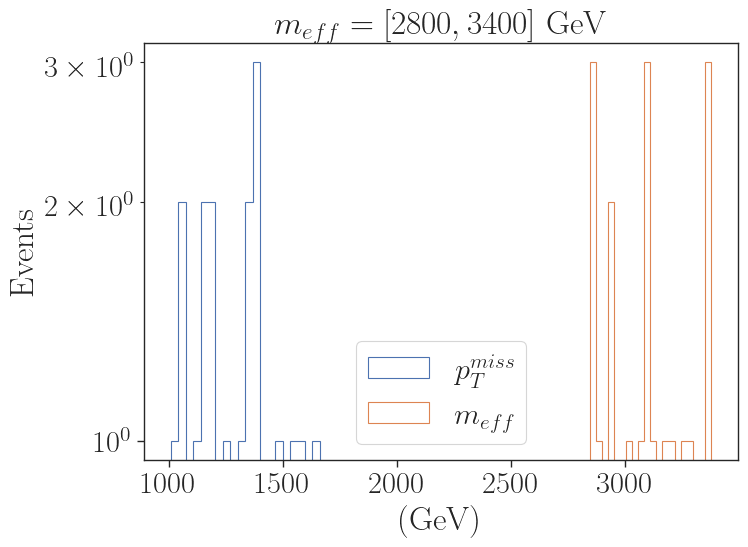

In [11]:
plt.figure(figsize=(8,6))
plt.hist(metAll['meff'], bins=20, label=r'$p_{T}^{miss}$', histtype='step')
plt.hist(meffAll['meff'], bins=20, label=r'$m_{eff}$', histtype='step')

plt.title(r'$m_{eff} = [2800,3400]$ GeV')
plt.legend()
plt.yscale('log')
plt.xlabel(r'(GeV)')
plt.ylabel('Events')
plt.tight_layout()
# plt.savefig('./BM-atlas-cuts-meff-met-final.png')
plt.show()

In [9]:
inputFiles = ['../DMSimp_vector_0j_2500_300/Events/run_01/vector_2500_300_delphes_events.root',
              '../DMSimp_vector_1j_2500_300/Events/run_01/vector_2500_300_delphes_events.root']

In [13]:
# ## Cuts
## jets
pTcut = 150.
pTj1min = 100.
pTjmin = 20.
etamax = 2.4
## MET
minMET = 250.
## Electrons
pTmin_el = 10.
etamax_el = 2.5
nMax_el = 0
## Photons
pTmin_a = 15.
etamax_a = 2.5
nMax_a = 0
## Muons
pTmin_mu = 10.
etamax_mu = 2.4
nMax_mu = 0
## Tau jets
nMax_tau = 0
etatau_max = 2.3
pTtau_min = 18.0
## b jets
nMax_b = 0
etab_max = 2.4
pTb_min = 20.0

lumTot = 137.2
yields = []
metAll = []
totalweightPB = 0.0
# Keep track of yields for each dataset
cutFlowAll = {'Fullsample' : 0.0,
                'Triggeremulation' : 0.0,
                '$p_{T}^{miss}>250$GeV' : 0.0, 
                'Electronveto' : 0.0,
                'Muonveto' : 0.0, 
                'Tauveto' : 0.0, 
                'Bjetveto' : 0.0, 
                'Photonveto' : 0.0,
                '$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad' : 0.0,
                'LeadingAK4jet$p_{T}>100$GeV' : 0.0, 
                'LeadingAK4jet$\eta<2.4$' : 0.0,    
                'SR_2016_18': 0.0}

ntotal = 0
for inputFile in inputFiles:
    f = ROOT.TFile(inputFile,'read')
    tree = f.Get("Delphes")
    nevts = tree.GetEntries()
    norm = 1.0

    for ievt in range(nevts):    

        ntotal += 1
        tree.GetEntry(ievt)        

        jets = tree.Jet
        try:
            weightPB = tree.Weight.At(1).Weight
        except:
            weightPB = tree.Weight.At(0).Weight
        weightPB = weightPB*norm
        ns = weightPB*1e3*lumTot # number of signal events
        totalweightPB += weightPB

        missingET = tree.MissingET.At(0)
    #         missingET = tree.GenMissingET.At(0)  # USE REAL MISSING ET!
        electrons = tree.Electron
        muons = tree.Muon
        photons = tree.Photon

        # Filter electrons:
        electronList = []
        for iel in range(electrons.GetEntries()):
            electron = electrons.At(iel)
            if electron.PT < pTmin_el:
                continue
            if abs(electron.Eta) > etamax_el:
                continue
            electronList.append(electron)

        # Filter muons:
        muonList = []
        for imu in range(muons.GetEntries()):
            muon = muons.At(imu)
            if muon.PT < pTmin_mu:
                continue
            if abs(muon.Eta) > etamax_mu:
                continue
            muonList.append(muon)

        # Filter photons:
        photonList = []
        for ia in range(photons.GetEntries()):
            photon = photons.At(ia)
            if photon.PT < pTmin_a:
                continue
            if abs(photon.Eta) > etamax_a:
                continue
            photonList.append(photon)            

        # Filter jets
        jetList = []
        bjetList = []
        taujetList = []
        for ijet in range(jets.GetEntries()):
            jet = jets.At(ijet)
            if jet.BTag and jet.PT > pTb_min and abs(jet.Eta) < etab_max:
                bjetList.append(jet)
            elif jet.TauTag and jet.PT > pTtau_min and abs(jet.Eta) < etatau_max:
                taujetList.append(jet)
            elif jet.PT > pTjmin and abs(jet.Eta) < etamax:
                jetList.append(jet)  
        jetList = sorted(jetList, key = lambda j: j.PT, reverse=True)    

        if len(jetList) > 0:
            deltaPhi = np.abs(jetList[0].Phi-missingET.Phi) 
        else:
            deltaPhi = 0.0

#         # Apply cut on DM pT to reproduce CMS
#         # cut on event generation:
#         dmMET = tree.DMMissingET.At(0).MET
#         if dmMET < pTcut:
#             continue


        cutFlow = cutFlowAll
        cutFlow['Fullsample'] += ns

        # Apply cuts:
        ## Apply trigger efficiency
        # ns = ns*triggerEff
        if missingET.MET < 120.0:
            continue
        cutFlow['Triggeremulation'] += ns

        ## Cut on MET
        if missingET.MET < minMET: continue              
        cutFlow['$p_{T}^{miss}>250$GeV'] += ns
        ## Veto electrons
        if len(electronList) > nMax_el: continue  
        cutFlow['Electronveto'] += ns
        ## Veto muons
        if len(muonList) > nMax_mu: continue  
        cutFlow['Muonveto'] += ns
        ## Veto tau jets
        if len(taujetList) > nMax_tau: continue  
        cutFlow['Tauveto'] += ns
        ## Veto b jets
        if len(bjetList) > nMax_b: continue  
        cutFlow['Bjetveto'] += ns
        ## Veto photons
        if len(photonList) > nMax_a: continue  
        cutFlow['Photonveto'] += ns
        ## Delta Phi cut
        if deltaPhi < 0.5: continue
        cutFlow['$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad'] += ns
        ## Jet cuts
        if len(jetList) < 1 or jetList[0].PT < pTj1min: continue
        cutFlow['LeadingAK4jet$p_{T}>100$GeV'] += ns
        if abs(jetList[0].Eta) > etamax: continue
        cutFlow['LeadingAK4jet$\eta<2.4$'] += ns
        if missingET.MET < 960. or missingET.MET > 1020: continue
        cutFlow['SR_2016_18'] += ns

        # Store relevant data        
        yields.append(ns)
        metAll.append(missingET.MET)  

    f.Close()

print('\nCross-section (pb) = %1.3e\n' %totalweightPB)

for key,val in cutFlowAll.items():
    if key == 'Fullsample':
        continue
    cutFlowAll[key] = val/cutFlowAll['Fullsample']
cutFlowAll['Fullsample'] = 1.0


Cross-section (pb) = 1.007e-01



In [14]:
cutFlowAll

{'Fullsample': 1.0,
 'Triggeremulation': 0.24023080924899645,
 '$p_{T}^{miss}>250$GeV': 0.08518913342406431,
 'Electronveto': 0.08515586263786375,
 'Muonveto': 0.08510126503618622,
 'Tauveto': 0.08294211117691581,
 'Bjetveto': 0.07325087467795702,
 'Photonveto': 0.07097589911317358,
 '$\\Delta \\phi (jet,p_{T}^{miss})>0.5$ rad': 0.0707979565503459,
 'LeadingAK4jet$p_{T}>100$GeV': 0.07026172393858478,
 'LeadingAK4jet$\\eta<2.4$': 0.07026172393858478,
 'SR_2016_18': 0.0003966710740404883}

In [54]:
metBins = [250,  280,  310,  340,  370,  400,  430,  470,  510, 550,  590,  640,  690,  
            740,  790,  840,  900,  960, 1020, 1090, 1160, 1250, 99999]

In [55]:
met = metAll
ns = np.array(yields)
binc,binEdges = np.histogram(met,bins=metBins, weights=ns)

In [56]:
binc

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 5.47823738, 0.        , 0.        ,
       0.        , 0.        ])

In [61]:
5.47823738/(totalweightPB*1e3*lumTot)

0.0003966710738954233

In [62]:
0.0003966710738954233*(36.0/lumTot)

0.00010408278906876997

In [50]:
# ## Cuts
## jets
pTcut = 0.
pTj1min = 100.
pTjmin = 20.
etamax = 2.4
## MET
minMET = 250.
## Electrons
pTmin_el = 10.
etamax_el = 2.5
nMax_el = 0
## Photons
pTmin_a = 15.
etamax_a = 2.5
nMax_a = 0
## Muons
pTmin_mu = 10.
etamax_mu = 2.4
nMax_mu = 0
## Tau jets
nMax_tau = 0
etatau_max = 2.3
pTtau_min = 18.0
## b jets
nMax_b = 0
etab_max = 2.4
pTb_min = 20.0

lumTot = 137.2
yields = []
metAll = []
totalweightPB = 0.0
# Keep track of yields for each dataset
cutFlowAll = {'Fullsample' : 0.0,
                'Triggeremulation' : 0.0,
                '$p_{T}^{miss}>250$GeV' : 0.0, 
                'Electronveto' : 0.0,
                'Muonveto' : 0.0, 
                'Tauveto' : 0.0, 
                'Bjetveto' : 0.0, 
                'Photonveto' : 0.0,
                '$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad' : 0.0,
                'LeadingAK4jet$p_{T}>100$GeV' : 0.0, 
                'LeadingAK4jet$\eta<2.4$' : 0.0,    
                'SR_2016_18': 0.0}

ntotal = 0
for inputFile in inputFiles:
    f = ROOT.TFile(inputFile,'read')
    tree = f.Get("Delphes")
    nevts = tree.GetEntries()
    norm = 1.0

    for ievt in range(nevts):    

        ntotal += 1
        tree.GetEntry(ievt)        

        jets = tree.Jet
        try:
            weightPB = tree.Weight.At(1).Weight
        except:
            weightPB = tree.Weight.At(0).Weight
        weightPB = weightPB*norm
        ns = weightPB*1e3*lumTot # number of signal events
        totalweightPB += weightPB

        missingET = tree.MissingET.At(0)
    #         missingET = tree.GenMissingET.At(0)  # USE REAL MISSING ET!
        electrons = tree.Electron
        muons = tree.Muon
        photons = tree.Photon

        # Filter electrons:
        electronList = []
        for iel in range(electrons.GetEntries()):
            electron = electrons.At(iel)
            if electron.PT < pTmin_el:
                continue
            if abs(electron.Eta) > etamax_el:
                continue
            electronList.append(electron)

        # Filter muons:
        muonList = []
        for imu in range(muons.GetEntries()):
            muon = muons.At(imu)
            if muon.PT < pTmin_mu:
                continue
            if abs(muon.Eta) > etamax_mu:
                continue
            muonList.append(muon)

        # Filter photons:
        photonList = []
        for ia in range(photons.GetEntries()):
            photon = photons.At(ia)
            if photon.PT < pTmin_a:
                continue
            if abs(photon.Eta) > etamax_a:
                continue
            photonList.append(photon)            

        # Filter jets
        jetList = []
        bjetList = []
        taujetList = []
        for ijet in range(jets.GetEntries()):
            jet = jets.At(ijet)
            if jet.BTag and jet.PT > pTb_min and abs(jet.Eta) < etab_max:
                bjetList.append(jet)
            elif jet.TauTag and jet.PT > pTtau_min and abs(jet.Eta) < etatau_max:
                taujetList.append(jet)
            elif jet.PT > pTjmin and abs(jet.Eta) < etamax:
                jetList.append(jet)  
        jetList = sorted(jetList, key = lambda j: j.PT, reverse=True)    

        if len(jetList) > 0:
            deltaPhi = np.abs(jetList[0].Phi-missingET.Phi) 
        else:
            deltaPhi = 0.0

        # Apply cut on DM pT to reproduce CMS
        # cut on event generation:
        dmMET = tree.DMMissingET.At(0).MET
        if dmMET < pTcut:
            continue


        cutFlow = cutFlowAll
        cutFlow['Fullsample'] += ns

        # Apply cuts:
        ## Apply trigger efficiency
        # ns = ns*triggerEff
        if missingET.MET < 120.0:
            continue
        cutFlow['Triggeremulation'] += ns

        ## Cut on MET
        if missingET.MET < minMET: continue              
        cutFlow['$p_{T}^{miss}>250$GeV'] += ns
        ## Veto electrons
        if len(electronList) > nMax_el: continue  
        cutFlow['Electronveto'] += ns
        ## Veto muons
        if len(muonList) > nMax_mu: continue  
        cutFlow['Muonveto'] += ns
        ## Veto tau jets
        if len(taujetList) > nMax_tau: continue  
        cutFlow['Tauveto'] += ns
        ## Veto b jets
        if len(bjetList) > nMax_b: continue  
        cutFlow['Bjetveto'] += ns
        ## Veto photons
        if len(photonList) > nMax_a: continue  
        cutFlow['Photonveto'] += ns
        ## Delta Phi cut
        if deltaPhi < 0.5: continue
        cutFlow['$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad'] += ns
        ## Jet cuts
        if len(jetList) < 1 or jetList[0].PT < pTj1min: continue
        cutFlow['LeadingAK4jet$p_{T}>100$GeV'] += ns
        if abs(jetList[0].Eta) > etamax: continue
        cutFlow['LeadingAK4jet$\eta<2.4$'] += ns
        if missingET.MET < 960. or missingET.MET > 1020: continue
        cutFlow['SR_2016_18'] += ns*(36.0/lumTot)

        # Store relevant data        
        yields.append(ns)
        metAll.append(missingET.MET)  

    f.Close()

print('\nCross-section (pb) = %1.3e\n' %totalweightPB)

for key,val in cutFlowAll.items():
    if key == 'Fullsample':
        continue
    cutFlowAll[key] = val/cutFlowAll['Fullsample']
cutFlowAll['Fullsample'] = 1.0


Cross-section (pb) = 1.007e-01



In [51]:
cutFlowAll

{'Fullsample': 1.0,
 'Triggeremulation': 0.24023080924899645,
 '$p_{T}^{miss}>250$GeV': 0.08518913342406431,
 'Electronveto': 0.08515586263786375,
 'Muonveto': 0.08510126503618622,
 'Tauveto': 0.08294211117691581,
 'Bjetveto': 0.07325087467795702,
 'Photonveto': 0.07097589911317358,
 '$\\Delta \\phi (jet,p_{T}^{miss})>0.5$ rad': 0.0707979565503459,
 'LeadingAK4jet$p_{T}>100$GeV': 0.07026172393858478,
 'LeadingAK4jet$\\eta<2.4$': 0.07026172393858478,
 'SR_2016_18': 0.00010408278910683365}

In [47]:
36/lumTot

0.2623906705539359

In [12]:
pd.set_option('display.max_columns', 200)

In [13]:
pd.read_pickle('../DMSimp_vector_0j_2500_300/Events/run_01/vector_2500_300_cms_exo_20_004_nocut.pcl')

,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,bin_280.0_310.0_ErrorPlus,bin_280.0_310.0_ErrorMinus,bin_310.0_340.0,bin_310.0_340.0_ErrorPlus,bin_310.0_340.0_ErrorMinus,bin_340.0_370.0,bin_340.0_370.0_ErrorPlus,bin_340.0_370.0_ErrorMinus,bin_370.0_400.0,bin_370.0_400.0_ErrorPlus,bin_370.0_400.0_ErrorMinus,bin_400.0_430.0,bin_400.0_430.0_ErrorPlus,bin_400.0_430.0_ErrorMinus,bin_430.0_470.0,bin_430.0_470.0_ErrorPlus,bin_430.0_470.0_ErrorMinus,bin_470.0_510.0,bin_470.0_510.0_ErrorPlus,bin_470.0_510.0_ErrorMinus,bin_510.0_550.0,bin_510.0_550.0_ErrorPlus,bin_510.0_550.0_ErrorMinus,bin_550.0_590.0,bin_550.0_590.0_ErrorPlus,bin_550.0_590.0_ErrorMinus,bin_590.0_640.0,bin_590.0_640.0_ErrorPlus,bin_590.0_640.0_ErrorMinus,bin_640.0_690.0,bin_640.0_690.0_ErrorPlus,bin_640.0_690.0_ErrorMinus,bin_690.0_740.0,bin_690.0_740.0_ErrorPlus,bin_690.0_740.0_ErrorMinus,bin_740.0_790.0,bin_740.0_790.0_ErrorPlus,bin_740.0_790.0_ErrorMinus,bin_790.0_840.0,bin_790.0_840.0_ErrorPlus,bin_790.0_840.0_ErrorMinus,bin_840.0_900.0,bin_840.0_900.0_ErrorPlus,bin_840.0_900.0_ErrorMinus,bin_900.0_960.0,bin_900.0_960.0_ErrorPlus,bin_900.0_960.0_ErrorMinus,bin_960.0_1020.0,bin_960.0_1020.0_ErrorPlus,bin_960.0_1020.0_ErrorMinus,bin_1020.0_1090.0,bin_1020.0_1090.0_ErrorPlus,bin_1020.0_1090.0_ErrorMinus,bin_1090.0_1160.0,bin_1090.0_1160.0_ErrorPlus,bin_1090.0_1160.0_ErrorMinus,bin_1160.0_1250.0,bin_1160.0_1250.0_ErrorPlus,bin_1160.0_1250.0_ErrorMinus,bin_1250.0_1400.0,bin_1250.0_1400.0_ErrorPlus,bin_1250.0_1400.0_ErrorMinus,Coupling,Mode,$m_{med}$,$m_{DM}$,$g_{DM}$,$g_{q}$,Total MC Events,Total xsec-pT150 (pb),Total xsec (pb),Fullsample,Triggeremulation,$p_{T}^{miss}>250$GeV,Electronveto,Muonveto,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$)
0,2016,36.0,46.391171,2.487447,2.487447,31.236261,1.708302,1.708302,31.100535,1.521276,1.521276,22.235768,1.264117,1.264117,19.915407,0.968589,0.968589,15.326271,0.754079,0.754079,16.932859,0.777764,0.777764,12.016508,0.582169,0.582169,11.111034,0.534167,0.534167,8.619943,0.448276,0.448276,8.320956,0.377127,0.377127,6.334804,0.331311,0.331311,4.991900,0.265862,0.265862,4.190963,0.278305,0.278305,2.689780,0.191499,0.191499,2.722868,0.175678,0.175678,1.937905,0.139425,0.139425,1.569205,0.175538,0.175538,1.237739,0.098091,0.098091,0.869298,0.133831,0.133831,0.801217,0.076518,0.076518,1.494168,0.080522,0.080522,Vector,DM+QCDjets,2500.0,300.0,1.0,0.25,139640,0.10066,0.10066,1.0,0.242262,0.085138,0.085131,0.085020,0.082477,0.072436,0.070205,0.069865,0.069253,0.069253,0.069253,0.069253
1,2017,41.5,55.180190,2.693634,2.693634,39.356551,1.929469,1.929469,32.671611,1.577558,1.577558,28.855211,1.349956,1.349956,21.951037,1.020487,1.020487,19.435470,0.961552,0.961552,19.156611,0.766565,0.766565,14.639947,0.703030,0.703030,11.737418,0.520024,0.520024,10.042322,0.460182,0.460182,10.189594,0.446324,0.446324,7.405219,0.356235,0.356235,5.647088,0.262631,0.262631,4.341643,0.210263,0.210263,3.076189,0.199101,0.199101,3.085684,0.181153,0.181153,2.441274,0.193849,0.193849,1.684676,0.120249,0.120249,1.523011,0.096821,0.096821,1.124720,0.194986,0.194986,0.682276,0.066413,0.066413,1.710994,0.085126,0.085126,Vector,DM+QCDjets,2500.0,300.0,1.0,0.25,139640,0.10066,0.10066,1.0,0.239393,0.085400,0.085340,0.085317,0.083457,0.073949,0.071413,0.071280,0.070854,0.070854,0.070854,0.070854
2,2018,59.7,64.021253,2.853848,2.853848,48.028057,2.072824,2.072824,38.624563,1.644263,1.644263,31.767840,1.426013,1.426013,25.853646,1.170124,1.170124,20.826418,0.891494,0.891494,23.304515,0.896164,0.896164,19.890728,0.719858,0.719858,16.372183,0.599320,0.599320,13.252245,0.526177,0.526177,13.090503,0.513696,0.513696,10.463585,0.437738,0.437738,8.057937,0.383591,0.383591,6.111448,0.296683,0.296683,4.747111,0.241266,0.241266,3.902446,0.202291,0.202291,3.293176,0.193040,0.193040,2.1